In [174]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import os
import sklearn
import umap.umap_ as umap



In [173]:
path_save = '/home/rfit/Telescope_Array/phd_work/src/train_VAE/runs_tests_Kharuk_one_work'

In [3]:
os.listdir(path_save)

['photon', 'pr']

In [4]:
os.listdir(os.path.join(path_save, 'pr'))

['recos.npy',
 'preds_num_det.npy',
 'num_det.npy',
 'recon_loss.npy',
 'embading.npy',
 'preds_log_var.npy',
 'loss_num_det.npy']

In [5]:
num_det_pr = np.load(os.path.join(path_save, 'pr', 'num_det.npy'))
num_det_photon = np.load(os.path.join(path_save, 'photon', 'num_det.npy'))
num_det_pr.shape, num_det_photon.shape, num_det_pr[:20]

((210315,),
 (210851,),
 array([ 8.,  9., 15.,  9., 13., 10.,  7.,  7.,  9., 11., 12., 19., 10.,
        13., 12.,  7., 12., 12.,  8., 17.]))

In [6]:
recon_loss_pr = np.load(os.path.join(path_save, 'pr', 'recon_loss.npy'))
recon_loss_photon = np.load(os.path.join(path_save, 'photon', 'recon_loss.npy'))
recon_loss_pr.shape, recon_loss_photon.shape, recon_loss_pr[:20]

((210315,),
 (210851,),
 array([0.00518217, 0.00550396, 0.00802776, 0.00498983, 0.00633101,
        0.0099944 , 0.01250802, 0.01005772, 0.00359017, 0.01911275,
        0.0164297 , 0.00963807, 0.00713021, 0.01691288, 0.01571645,
        0.00838905, 0.01679318, 0.00967955, 0.00533442, 0.00993051]))

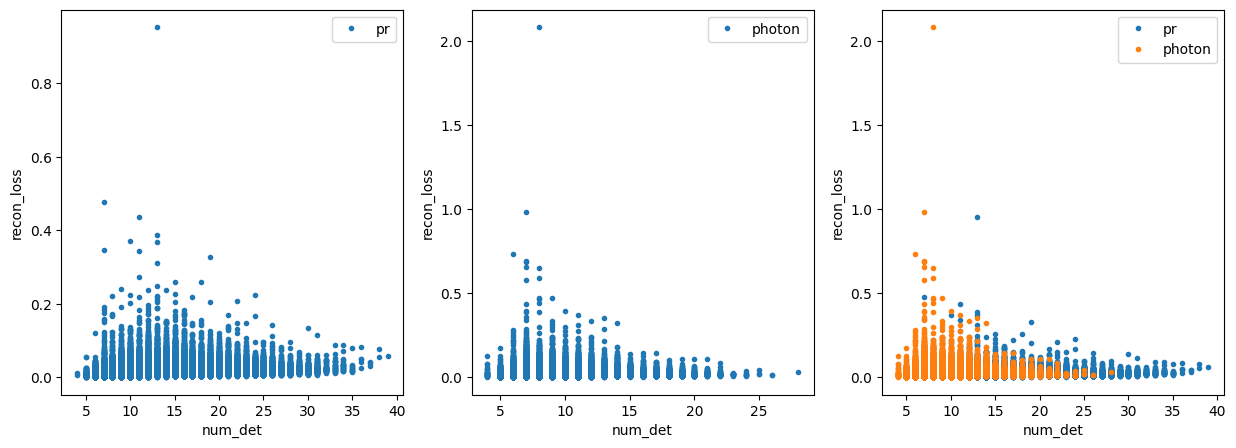

In [7]:
fig, ax = plt.subplots(1,3, figsize=(15, 5))
ax[0].plot(num_det_pr, recon_loss_pr, '.', label='pr')
ax[0].legend()
ax[1].plot(num_det_photon, recon_loss_photon, '.', label='photon')
ax[1].legend()
ax[2].plot(num_det_pr, recon_loss_pr, '.', label='pr')
ax[2].plot(num_det_photon, recon_loss_photon, '.', label='photon')
ax[2].legend()
for i in range(3):
    ax[i].set_xlabel('num_det')
    ax[i].set_ylabel('recon_loss')
plt.show()


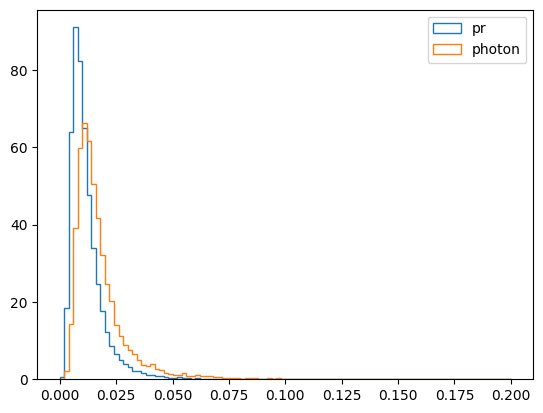

In [8]:
num=10
range_hist = (0,0.2)
plt.hist(recon_loss_pr[num_det_pr == num], density=True, bins=100, label='pr', histtype='step', range=range_hist)
plt.hist(recon_loss_photon[num_det_photon == num], density=True, bins=100, label='photon', histtype='step', range=range_hist)
plt.legend()
plt.show()




In [9]:
embading_pr = np.load(os.path.join(path_save, 'pr', 'embading.npy'))
embading_photon = np.load(os.path.join(path_save, 'photon', 'embading.npy'))
recos_pr = np.load(os.path.join(path_save, 'pr', 'recos.npy'))
recos_photon = np.load(os.path.join(path_save, 'photon', 'recos.npy'))
embading_pr.shape, embading_photon.shape, recos_pr.shape,





((210315, 8), (210851, 8), (210315, 15))

In [11]:
num_det_pr.shape, embading_pr.shape, recon_loss_pr.shape,  recos_pr.shape,

((210315,), (210315, 8), (210315,), (210315, 15))

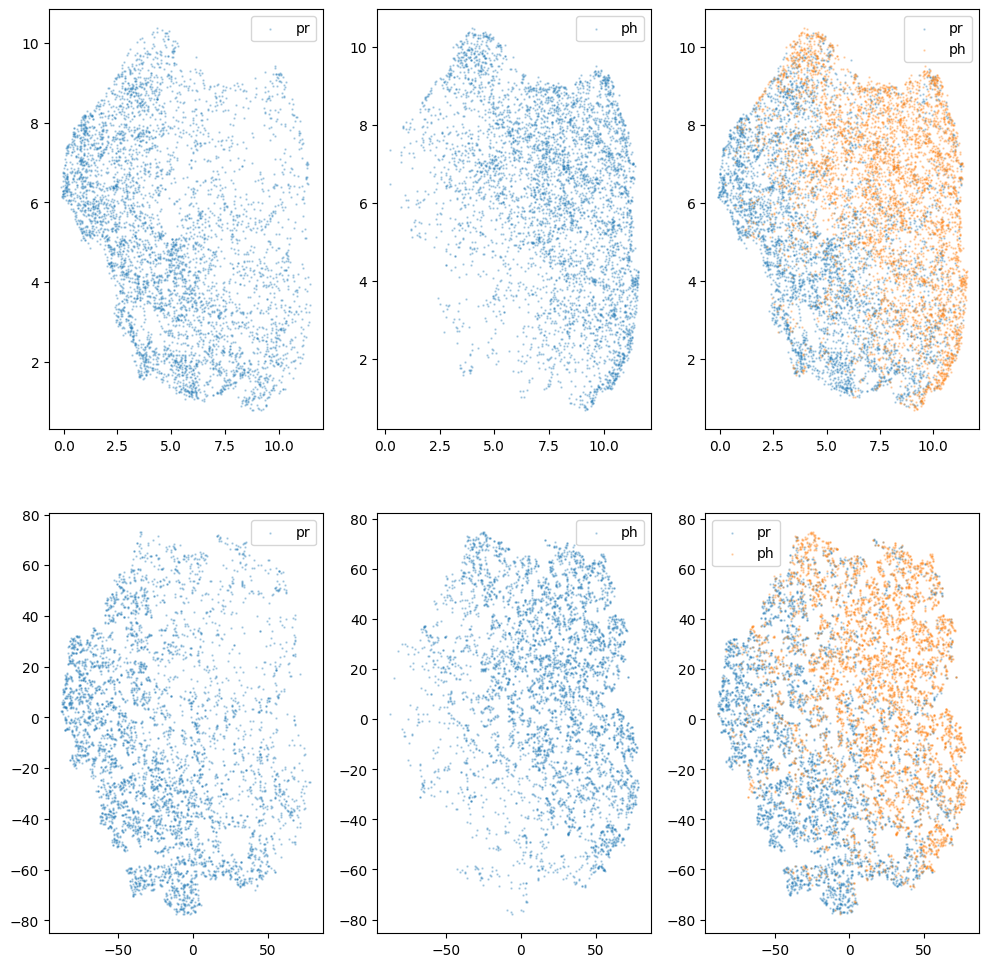

In [12]:
pr = embading_pr
ph = embading_photon

def show_2d(pr, ph, use_ph=True):
    pr_index= np.random.randint(0, pr.shape[0], size=5000)
    ph_index= np.random.randint(0, ph.shape[0], size=5000)
    pr = pr[pr_index]
    ph = ph[ph_index]
    reducer = umap.UMAP(n_components=2)
    if use_ph:
        manifold = reducer.fit(np.concatenate([pr, ph], axis=0))
    else:
        manifold = reducer.fit(pr)
    X_pr = manifold.transform(pr)
    X_ph = manifold.transform(ph)


    fig, ax = plt.subplots(2,3, figsize=(12, 12))
    ax_1, ax_2, ax_3 = ax[0]
    ax_1.scatter(X_pr[:, 0], X_pr[:, 1], s=0.5, alpha=0.3, label='pr')
    ax_2.scatter(X_ph[:, 0], X_ph[:, 1], s=0.5, alpha=0.3, label='ph')
    ax_3.scatter(X_pr[:, 0], X_pr[:, 1], s=0.5, alpha=0.3, label='pr')
    ax_3.scatter(X_ph[:, 0], X_ph[:, 1], s=0.5, alpha=0.3, label='ph')
    ax_1.legend()
    ax_2.legend()
    ax_3.legend()

    tsne = sklearn.manifold.TSNE(n_components=2)
    if use_ph:
        X_tsne = tsne.fit_transform(np.concatenate([pr, ph], axis=0))
        X_tsne_pr = X_tsne[:pr.shape[0]]
        X_tsne_ph = X_tsne[pr.shape[0]:]
    else:
        X_tsne = tsne.fit_transform(pr)
        X_tsne_pr = X_tsne

    ax_1, ax_2, ax_3 = ax[1]
    ax_1.scatter(X_tsne_pr[:, 0], X_tsne_pr[:, 1], s=0.5, alpha=0.3, label='pr')
    ax_2.scatter(X_tsne_ph[:, 0], X_tsne_ph[:, 1], s=0.5, alpha=0.3, label='ph')
    ax_3.scatter(X_tsne_pr[:, 0], X_tsne_pr[:, 1], s=0.5, alpha=0.3, label='pr')
    ax_3.scatter(X_tsne_ph[:, 0], X_tsne_ph[:, 1], s=0.5, alpha=0.3, label='ph')
    ax_1.legend()
    ax_2.legend()
    ax_3.legend()
    plt.show()



show_2d(pr, ph)








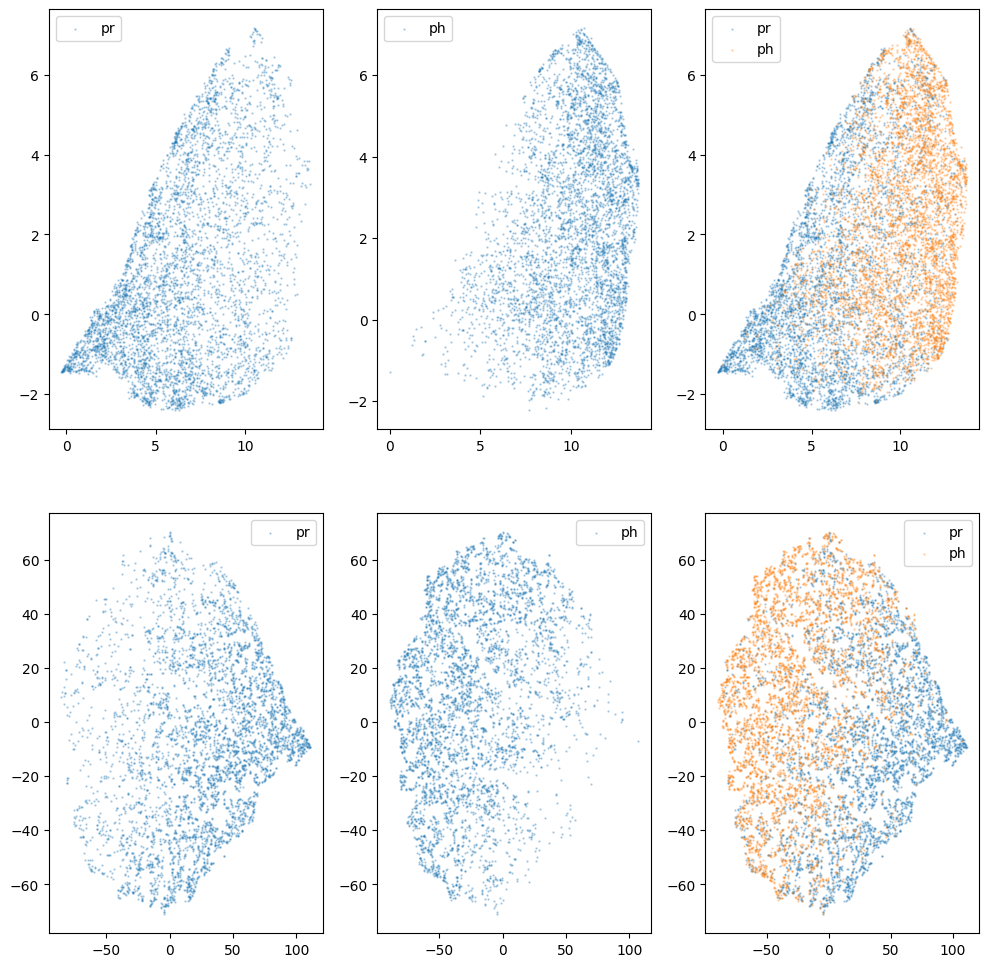

In [18]:
pr = np.concatenate([embading_pr, num_det_pr.reshape(-1,1)], axis=1)
ph = np.concatenate([embading_photon, num_det_photon.reshape(-1,1)], axis=1)
show_2d(pr, ph)

UnboundLocalError: local variable 'X_tsne_ph' referenced before assignment

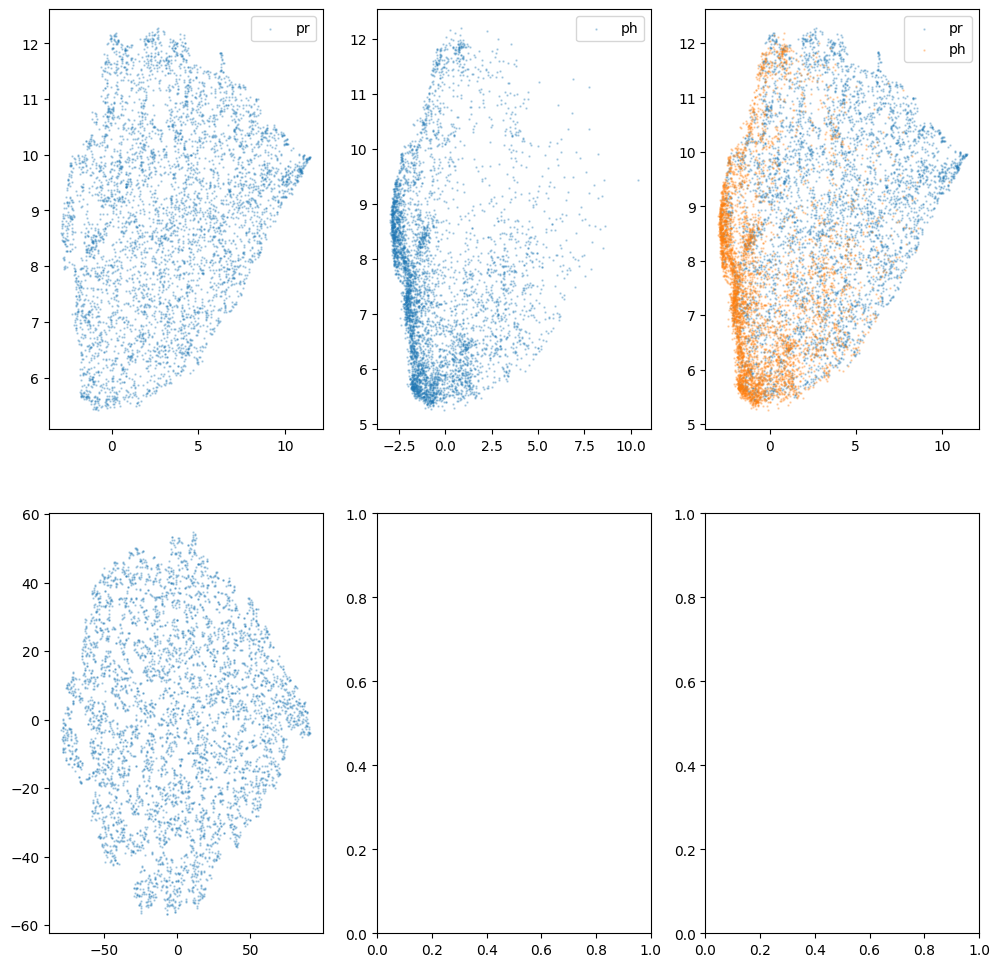

In [19]:
show_2d(pr, ph, use_ph=False)

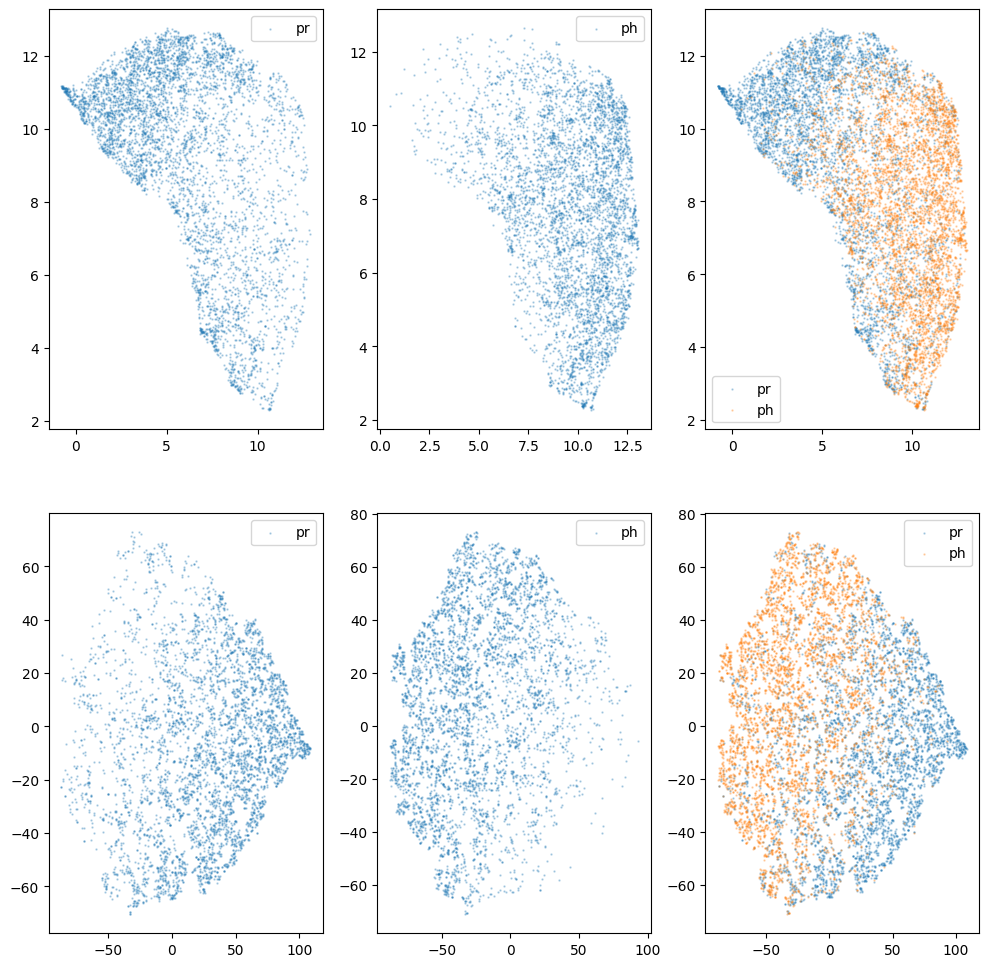

In [20]:
pr = np.concatenate([embading_pr, num_det_pr.reshape(-1,1), recon_loss_pr.reshape(-1,1)], axis=1)
ph = np.concatenate([embading_photon, num_det_photon.reshape(-1,1), recon_loss_photon.reshape(-1,1)], axis=1)
show_2d(pr, ph)

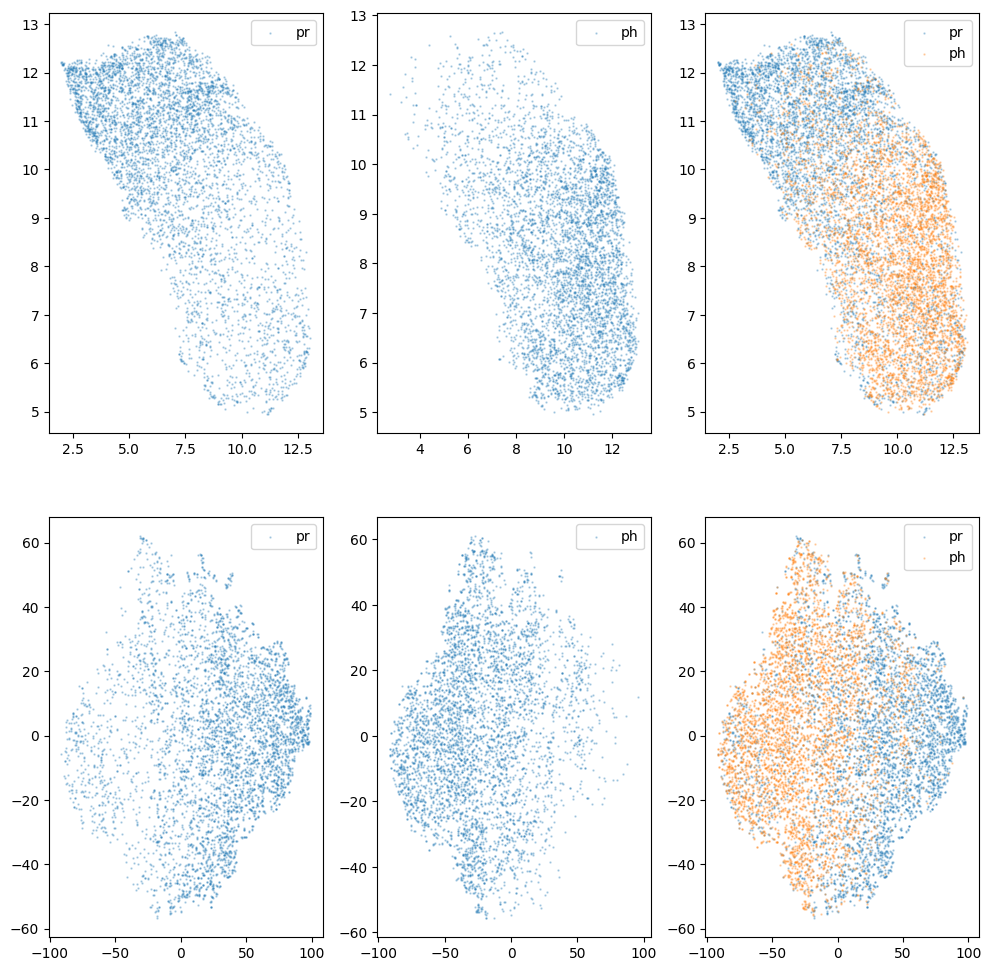

In [21]:
pr = np.concatenate([embading_pr, num_det_pr.reshape(-1,1), recon_loss_pr.reshape(-1,1), recos_pr], axis=1)
ph = np.concatenate([embading_photon, num_det_photon.reshape(-1,1), recon_loss_photon.reshape(-1,1), recos_photon], axis=1)
show_2d(pr, ph)

UnboundLocalError: local variable 'X_tsne_ph' referenced before assignment

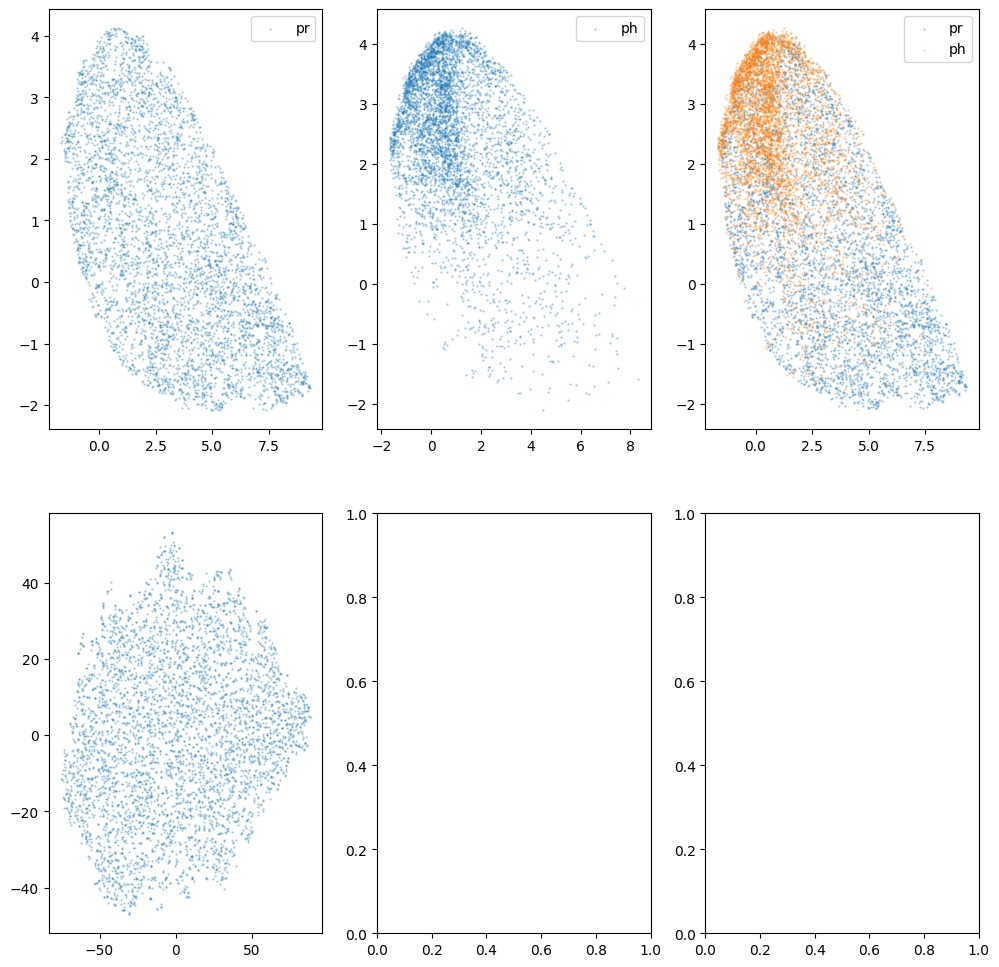

In [59]:
pr = np.concatenate([embading_pr, num_det_pr.reshape(-1,1), recon_loss_pr.reshape(-1,1), recos_pr], axis=1)
ph = np.concatenate([embading_photon, num_det_photon.reshape(-1,1), recon_loss_photon.reshape(-1,1), recos_photon], axis=1)
show_2d(pr, ph, use_ph=False)

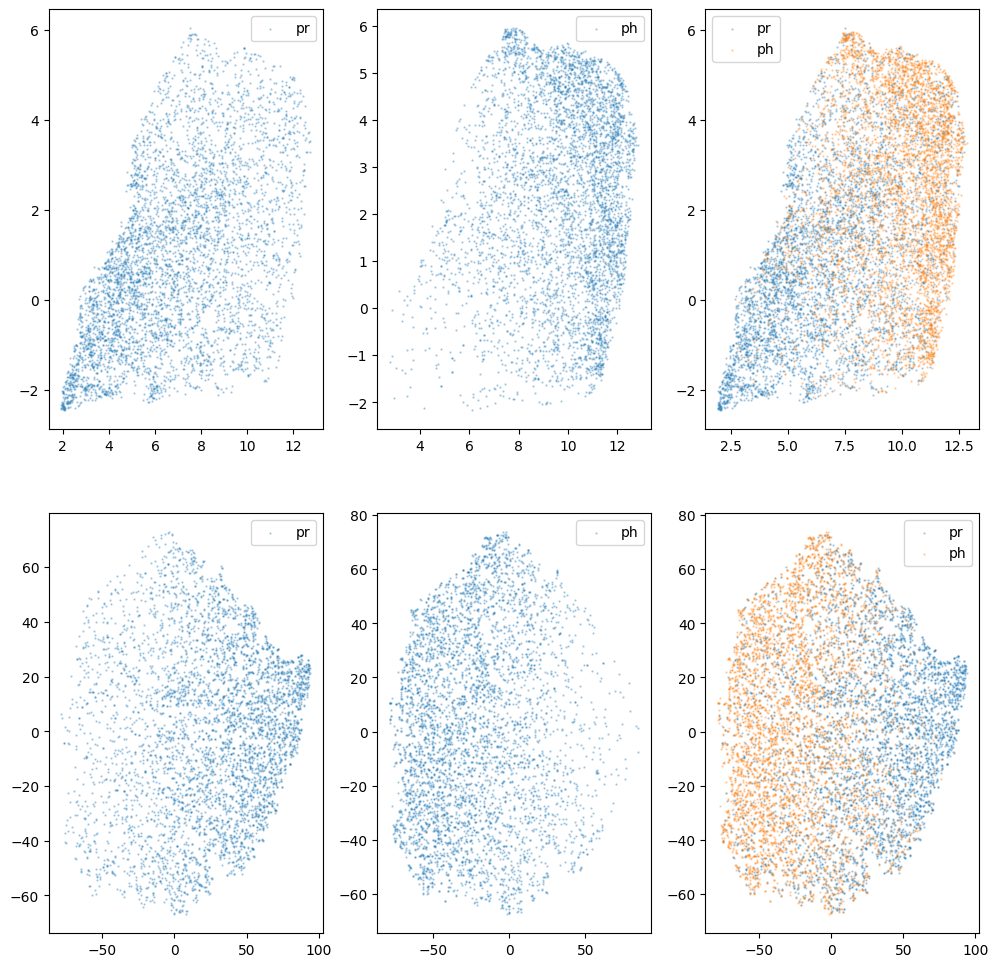

In [22]:
pr = np.concatenate([ num_det_pr.reshape(-1,1), recon_loss_pr.reshape(-1,1), recos_pr], axis=1)
ph = np.concatenate([ num_det_photon.reshape(-1,1), recon_loss_photon.reshape(-1,1), recos_photon], axis=1)
show_2d(pr, ph)

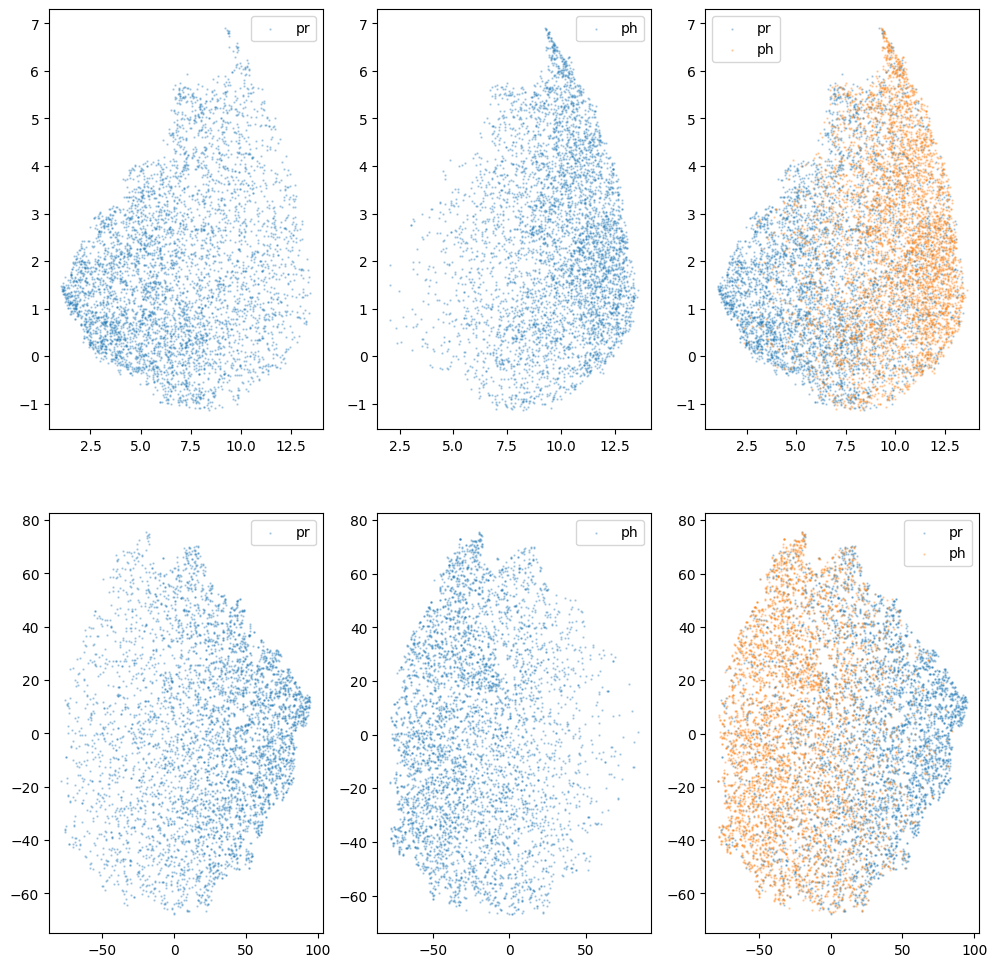

In [23]:
pr = np.concatenate([ num_det_pr.reshape(-1,1), recos_pr], axis=1)
ph = np.concatenate([ num_det_photon.reshape(-1,1), recos_photon], axis=1)
show_2d(pr, ph)

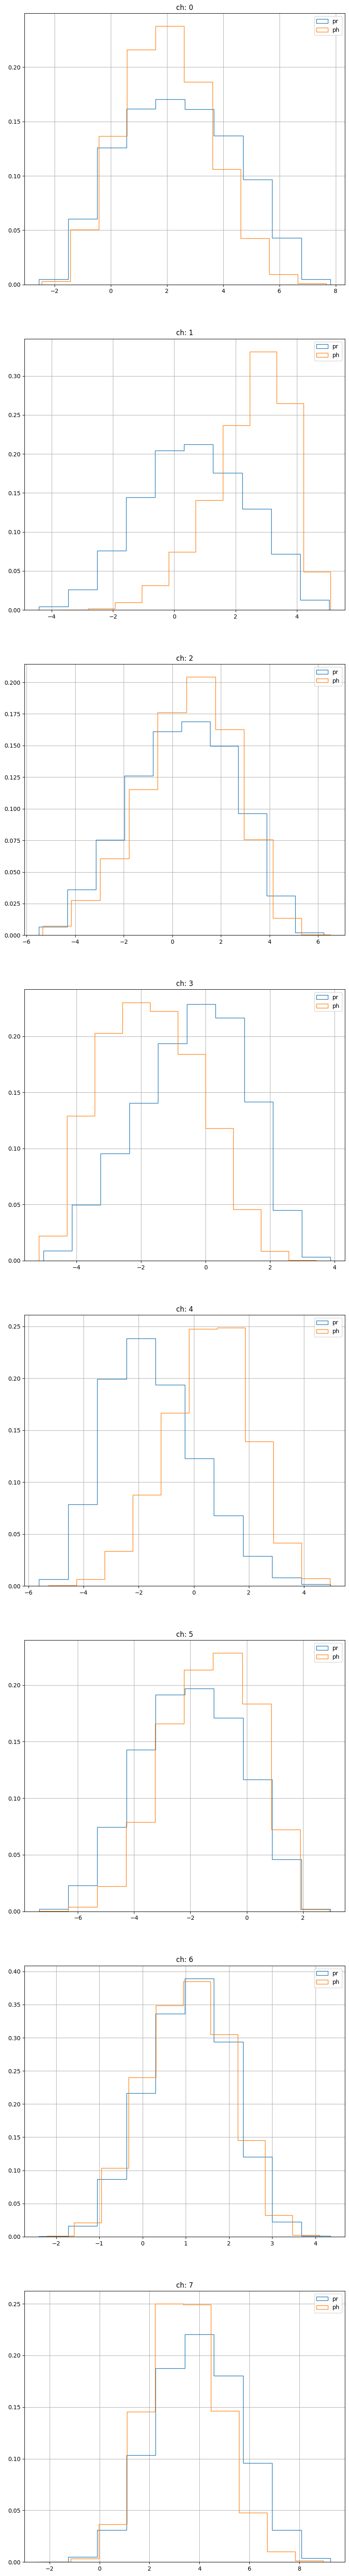

In [15]:
fig, axs = plt.subplots(8, 1, figsize=(10, 80))
for i in range(8):
    axs[i].hist(embading_pr[:, i], label='pr', histtype='step', density=True)
    axs[i].hist(embading_photon[:, i], label='ph', histtype='step', density=True)
    axs[i].legend()
    axs[i].set_title(f'ch: {i}')
    axs[i].grid()
plt.show()




In [25]:
# пример из sklearn

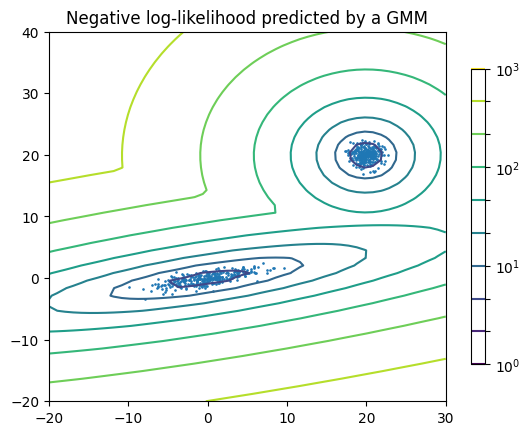

In [13]:
# Authors: The scikit-learn developers
# SPDX-License-Identifier: BSD-3-Clause

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm

from sklearn import mixture

n_samples = 300

# generate random sample, two components
np.random.seed(0)

# generate spherical data centered on (20, 20)
shifted_gaussian = np.random.randn(n_samples, 2) + np.array([20, 20])

# generate zero centered stretched Gaussian data
C = np.array([[0.0, -0.7], [3.5, 0.7]])
stretched_gaussian = np.dot(np.random.randn(n_samples, 2), C)

# concatenate the two datasets into the final training set
X_train = np.vstack([shifted_gaussian, stretched_gaussian])

# fit a Gaussian Mixture Model with two components
clf = mixture.GaussianMixture(n_components=2, covariance_type="full")
clf.fit(X_train)

# display predicted scores by the model as a contour plot
x = np.linspace(-20.0, 30.0)
y = np.linspace(-20.0, 40.0)
X, Y = np.meshgrid(x, y)
XX = np.array([X.ravel(), Y.ravel()]).T
Z = -clf.score_samples(XX)
Z = Z.reshape(X.shape)

CS = plt.contour(
    X, Y, Z, norm=LogNorm(vmin=1.0, vmax=1000.0), levels=np.logspace(0, 3, 10)
)
CB = plt.colorbar(CS, shrink=0.8, extend="both")
plt.scatter(X_train[:, 0], X_train[:, 1], 0.8)

plt.title("Negative log-likelihood predicted by a GMM")
plt.axis("tight")
plt.show()

In [14]:
clf = mixture.GaussianMixture(n_components=1, covariance_type="full")
clf.fit(embading_pr[:,:])
score_samples = clf.score_samples(embading_pr)
print(score_samples.shape, embading_pr[:,:].shape)


(210315,) (210315, 8)


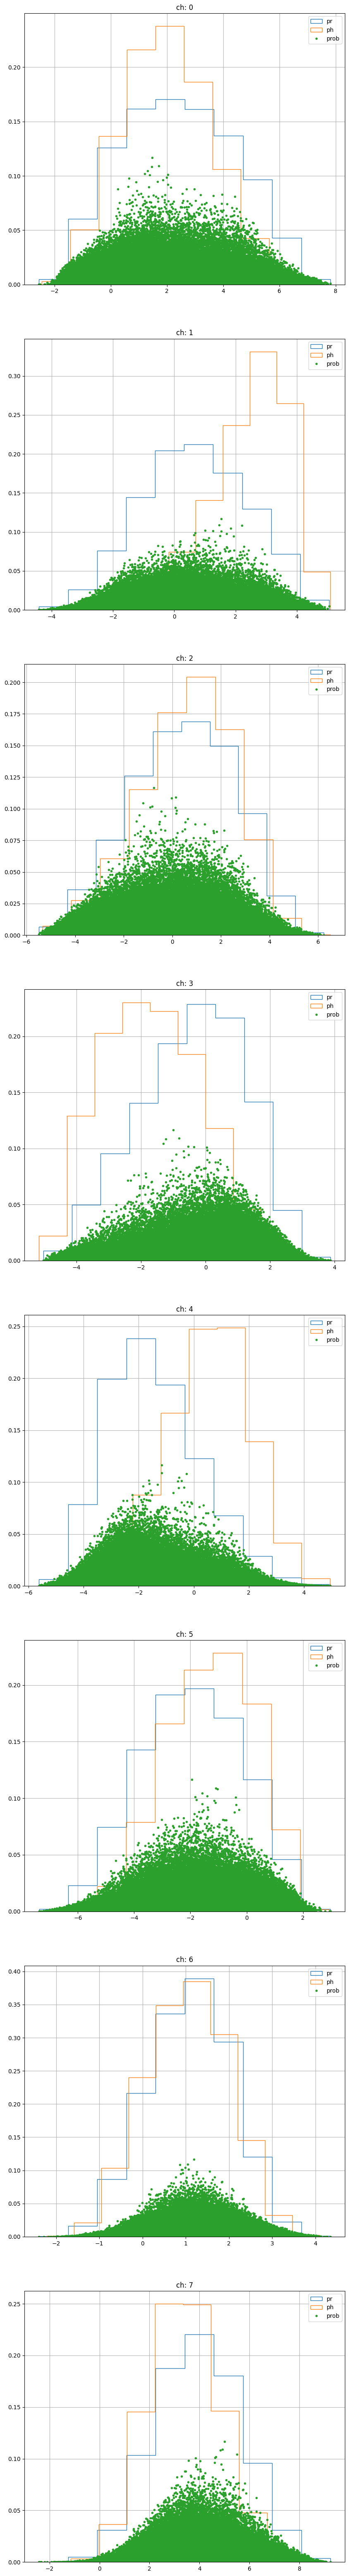

In [15]:
fig, axs = plt.subplots(8, 1, figsize=(10, 80))
clf = mixture.GaussianMixture(n_components=2, covariance_type="full")
# clf.fit(embading_pr[:, :])
for i in range(8):
    # clf = mixture.GaussianMixture(n_components=8, covariance_type="full")
    clf.fit(embading_pr[:, :])
    score_samples = clf.score_samples(embading_pr[:])


    index = np.argsort(embading_pr[:,i])

    prob = np.exp(score_samples)[index]
    axs[i].hist(embading_pr[:, i], label='pr', histtype='step', density=True)
    axs[i].hist(embading_photon[:, i], label='ph', histtype='step', density=True)
    axs[i].plot(embading_pr[index, i], prob*256, '.', label='prob')
    axs[i].legend()
    axs[i].set_title(f'ch: {i}')
    axs[i].grid()
plt.show()

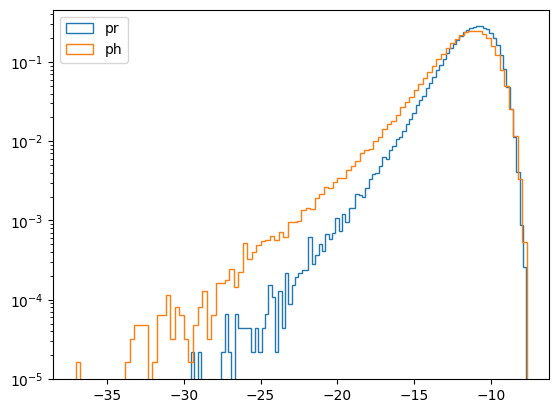

In [16]:
score_samples_photon = clf.score_samples(embading_photon)
plt.hist(score_samples, bins=100, label='pr', density=True, histtype ='step', log=True)
plt.hist(score_samples_photon, bins=100, label='ph', density=True, histtype ='step', log=True)
plt.legend()
plt.show()

In [17]:
def get_metrics(score_samples, score_samples_photon, th):
    FP_index = np.where(score_samples < th)[0]
    TP_index = np.where(score_samples_photon < th)[0]
    FN_index = np.where(score_samples_photon > th)[0]
    TN_index = np.where(score_samples > th)[0]
    part_anomalys_pr = len(FP_index)/len(score_samples)
    part_anomalys_ph = len(TP_index)/len(score_samples_photon)
    recall = len(TP_index) / (len(TP_index) + len(FN_index)+1e-10)
    precision = len(TP_index) / (len(TP_index) + len(FP_index)+1e-10)
    f1 = 2 * precision * recall / (precision + recall+1e-10)
    return recall, precision, f1, part_anomalys_pr, part_anomalys_ph


recall, precision, f1, part_anomalys_pr, part_anomalys_ph = get_metrics(score_samples, score_samples_photon, -9)
print(recall, precision, f1, part_anomalys_pr, part_anomalys_ph)

0.9812521638503015 0.5008715103273972 0.6632122026648641 0.9803295057413879 0.9812521638503019


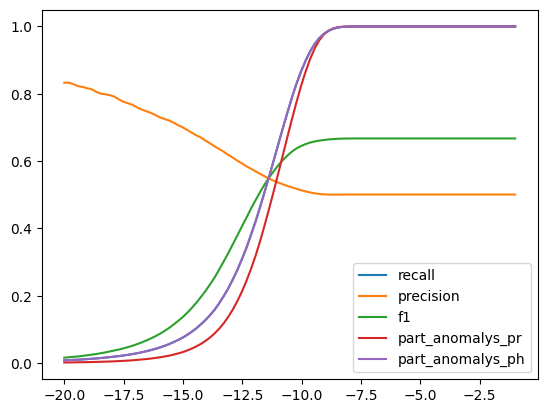

In [18]:
recall_list = []    
precision_list = []
f1_list = []
part_anomalys_pr_list = []
part_anomalys_ph_list = []
for th in np.linspace(-20, -1, 100):
    recall, precision, f1, part_anomalys_pr, part_anomalys_ph = get_metrics(score_samples, score_samples_photon, th)
    recall_list.append(recall)
    precision_list.append(precision)
    f1_list.append(f1)
    part_anomalys_pr_list.append(part_anomalys_pr)
    part_anomalys_ph_list.append(part_anomalys_ph)
plt.plot(np.linspace(-20, -1, 100), recall_list, label='recall')
plt.plot(np.linspace(-20, -1, 100), precision_list, label='precision')
plt.plot(np.linspace(-20, -1, 100), f1_list, label='f1')
plt.plot(np.linspace(-20, -1, 100), part_anomalys_pr_list, label='part_anomalys_pr')
plt.plot(np.linspace(-20, -1, 100), part_anomalys_ph_list, label='part_anomalys_ph')
plt.legend()
plt.show()


In [19]:
len(score_samples)

210315

In [22]:
#full test 
from sklearn.metrics import roc_curve, auc
from sklearn.neighbors import KernelDensity
def full_test_prob(feaches_pr, feaches_photon,feaches_pr_test = None,n_components=1, range_hist=(-20, 0)):
    fig, axs = plt.subplots(3, 1, figsize=(7, 15))
    # clf = mixture.GaussianMixture(n_components=n_components, covariance_type="full")
    clf = KernelDensity(kernel='gaussian', bandwidth=0.1)
    clf.fit(feaches_pr)
    if feaches_pr_test is None:
        score_samples = clf.score_samples(feaches_pr)
        score_samples_photon = clf.score_samples(feaches_photon)
    else:
        score_samples = clf.score_samples(feaches_pr_test)
        score_samples_photon = clf.score_samples(feaches_photon)
    print(score_samples)
    print(score_samples_photon)
    axs[0].hist(score_samples, bins=100, label='pr', histtype='step', density=True, range=range_hist)
    axs[0].hist(score_samples_photon, bins=100, label='ph', histtype='step', density=True, range=range_hist)
    axs[0].legend()
    axs[0].set_title('hist')
    axs[0].grid()

    recall_list = []    
    precision_list = []
    f1_list = []
    part_anomalys_pr_list = []
    part_anomalys_ph_list = []
    min_score = min(score_samples.min(), score_samples_photon.min())
    max_score = max(score_samples.max(), score_samples_photon.max())
    for th in np.linspace(min_score, max_score, 100):
        recall, precision, f1, part_anomalys_pr, part_anomalys_ph = get_metrics(score_samples, score_samples_photon, th)
        recall_list.append(recall)
        precision_list.append(precision)
        f1_list.append(f1)
        part_anomalys_pr_list.append(part_anomalys_pr)
        part_anomalys_ph_list.append(part_anomalys_ph)
    axs[1].plot(np.linspace(-20, 2, 100), recall_list, label='recall')
    axs[1].plot(np.linspace(-20, 2, 100), precision_list, label='precision')
    axs[1].plot(np.linspace(-20, 2, 100), f1_list, label='f1')
    axs[1].plot(np.linspace(-20, 2, 100), part_anomalys_pr_list, label='part_anomalys_pr')
    axs[1].plot(np.linspace(-20, 2, 100), part_anomalys_ph_list, label='part_anomalys_ph')
    axs[1].legend()
    axs[1].set_title('metrics')
    axs[1].grid()

    #roc curve
    label_pr = np.zeros_like(score_samples)
    label_ph = np.ones_like(score_samples_photon)
    label = np.concatenate((label_pr, label_ph))
    loss = np.concatenate((-score_samples, -score_samples_photon))
    fpr, tpr, thresholds = roc_curve(label, loss)
    auc_ = auc(fpr, tpr)
    axs[2].plot(fpr, tpr)
    axs[2].text(0.5, 0.5, f'auc: {auc_:.2f}', fontsize=12, ha='center', va='center')
    axs[2].set_title(f'roc curve')
    axs[2].grid()
    print(thresholds.min(), thresholds.max())
    plt.show()

    
    


[ -27.70639182  -25.32888023  -27.46937673  -55.95755693  -28.74839657
  -29.1143836   -25.95886965  -25.74376682  -68.37277015  -22.07180348
  -27.28467039  -24.73515623  -24.75114572  -44.49235756  -58.8842389
  -49.54328555  -97.32456402  -28.30077639  -26.9933968   -33.27918453
  -80.80896016  -58.35317392  -35.12294984  -26.28907849  -30.06662198
  -47.1510401   -37.44628666  -25.8838531   -67.2350438   -36.6020578
  -27.68432811  -45.94315787 -102.15314698  -48.89601433  -22.07609646
  -26.10098582  -18.59517525  -26.9855093   -24.15926491  -29.31893555
  -27.48966549   -4.1081554   -26.47434072  -55.04670239  -48.67882473
  -26.69136892  -68.91684055  -43.80383612  -42.476033    -27.48506656
  -25.57414931  -29.16152422  -43.80998907  -26.41646845  -71.53793839
  -38.4276726   -29.43118571  -27.62497581  -47.04795914  -41.46352093
  -26.1875729   -25.45355899  -65.69228232  -63.9737385   -47.66245619
  -82.37886929  -22.02971381  -33.61807191  -32.08622606  -45.25291458
  -31.30

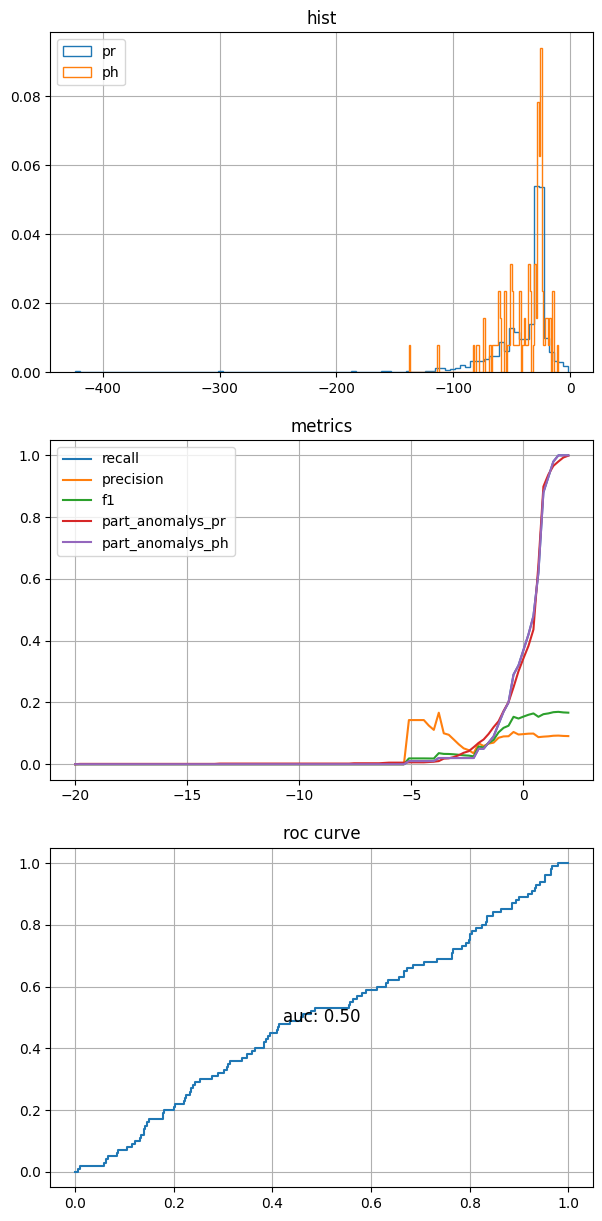

In [23]:
feaches_pr = embading_pr[:20000]
feaches_pr_test = embading_photon[-1000:] # 10k
feaches_photon = embading_photon[:100]
full_test_prob(feaches_pr, feaches_photon, feaches_pr_test = feaches_pr_test, n_components =3, range_hist=None)

In [147]:
num =200000
num_ph = 5000
print(f'part of data {num_ph/num}')
test_num = 10000

index = np.random.randint(0, len(embading_pr), num)
index_ph = np.random.randint(0, len(embading_photon), num_ph)
feaches_pr = np.concatenate([embading_pr[index], num_det_pr[index].reshape(-1,1), recon_loss_pr[index].reshape(-1,1)], axis=1)

feaches_photon = np.concatenate([embading_photon[index_ph], num_det_photon[index_ph].reshape(-1,1), recon_loss_photon[index_ph].reshape(-1,1)], axis=1)

feaches = np.concatenate([feaches_pr, feaches_photon], axis=0)

# label_pr = np.zeros(num)
# label_ph = np.ones(num_ph)
# label = np.concatenate((label_pr, label_ph))
# feaches_pr_test = np.concatenate([embading_pr[-test_num:], num_det_pr[-test_num:].reshape(-1,1), recon_loss_pr[-test_num:].reshape(-1,1)], axis=1)

# feaches_photon_test = np.concatenate([embading_photon[-test_num:], num_det_photon[-test_num:].reshape(-1,1), recon_loss_photon[-test_num:].reshape(-1,1)], axis=1)


# full_test_prob(feaches, feaches_photon_test, feaches_pr_test = feaches_pr_test, n_components = 3, range_hist=None)

part of data 0.025


15.367814667176571 inf


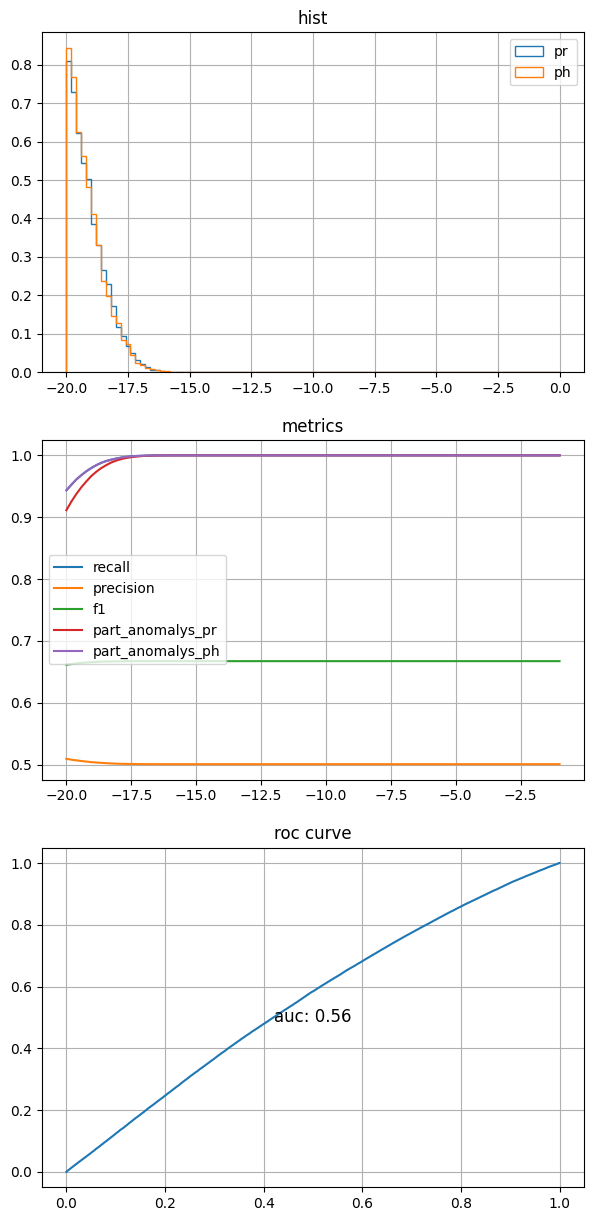

In [58]:
feaches_pr = np.concatenate([embading_pr, num_det_pr.reshape(-1,1), recon_loss_pr.reshape(-1,1), recos_pr], axis=1)
feaches_photon = np.concatenate([embading_photon, num_det_photon.reshape(-1,1), recon_loss_photon.reshape(-1,1), recos_photon], axis=1)

full_test_prob(feaches_pr, feaches_photon, range_hist=(-20, 0), n_components=1)

In [76]:
num =200000
num_ph = 5000
print(f'part of data {num_ph/num}')
test_num = 10000
feaches_pr = np.concatenate([embading_pr[:num], num_det_pr[:num].reshape(-1,1), recon_loss_pr[:num].reshape(-1,1)], axis=1)

feaches_photon = np.concatenate([embading_photon[:num_ph], num_det_photon[:num_ph].reshape(-1,1), recon_loss_photon[:num_ph].reshape(-1,1)], axis=1)

feaches = np.concatenate([feaches_pr, feaches_photon], axis=0)

label_pr = np.zeros(num)
label_ph = np.ones(num_ph)
label = np.concatenate((label_pr, label_ph))
feaches_pr_test = np.concatenate([embading_pr[-test_num:], num_det_pr[-test_num:].reshape(-1,1), recon_loss_pr[-test_num:].reshape(-1,1)], axis=1)

feaches_photon_test = np.concatenate([embading_photon[-test_num:], num_det_photon[-test_num:].reshape(-1,1), recon_loss_photon[-test_num:].reshape(-1,1)], axis=1)


part of data 0.025


In [ ]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import RobustScaler
from sklearn.neighbors import NearestNeighbors, LocalOutlierFactor
from sklearn.ensemble import IsolationForest

# feaches: твой массив shape [N, D]
X = feaches.copy()

# Лучше RobustScaler, чем StandardScaler, для задач с выбросами
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

def get_top_anomalies(scores, top_percent=1.0):
    """
    Возвращает индексы top_percent самых аномальных точек.
    Чем больше score, тем более аномальна точка.
    """
    n_top = max(1, int(len(scores) * top_percent / 100.0))
    idx_sorted = np.argsort(scores)[::-1]   # по убыванию anomaly score
    top_idx = idx_sorted[:n_top]
    return top_idx, scores[top_idx]

def make_result_df(scores, name="score"):
    df = pd.DataFrame({
        "index": np.arange(len(scores)),
        name: scores
    })
    df = df.sort_values(name, ascending=False).reset_index(drop=True)
    return df

In [27]:
def knn_anomaly_score(X_scaled, k=20):
    """
    Для каждой точки считает среднее расстояние до k ближайших соседей.
    Чем больше score, тем более аномальна точка.
    """
    nn = NearestNeighbors(n_neighbors=k + 1, metric="euclidean")
    nn.fit(X_scaled)

    distances, indices = nn.kneighbors(X_scaled)

    # distances[:, 0] = расстояние до самой себя = 0
    knn_distances = distances[:, 1:]  # убираем self-neighbor
    scores = knn_distances.mean(axis=1)

    return scores

knn_scores = knn_anomaly_score(X_scaled, k=20)

top_idx_knn, top_scores_knn = get_top_anomalies(knn_scores, top_percent=1.0)
df_knn = make_result_df(knn_scores, name="knn_score")

print(df_knn.head(20))

     index  knn_score
0   133482  70.951546
1   182243  20.715199
2   192482  16.613100
3    16090  12.110999
4    97746  11.027979
5    49765  10.612558
6    71170   9.562875
7   178248   9.229749
8    41170   8.620740
9    34444   7.928233
10  185673   5.658815
11   42082   4.689225
12  108152   4.615560
13   70502   3.704565
14  193193   3.617785
15    5282   3.522617
16  165680   3.504568
17   34324   3.255759
18   37162   3.247233
19   61305   3.246358


     index  knn_score particle
0   133482  70.951546       pr
1   182243  20.715199       pr
2   192482  16.613100       pr
3    16090  12.110999       pr
4    97746  11.027979       pr
5    49765  10.612558       pr
6    71170   9.562875       pr
7   178248   9.229749       pr
8    41170   8.620740       pr
9    34444   7.928233       pr
10  185673   5.658815       pr
11   42082   4.689225       pr
12  108152   4.615560       pr
13   70502   3.704565       pr
14  193193   3.617785       pr
15    5282   3.522617       pr
16  165680   3.504568       pr
17   34324   3.255759       pr
18   37162   3.247233       pr
19   61305   3.246358       pr
         index  knn_score particle
204980   82646   0.272638       pr
204981   32769   0.270865       pr
204982   71094   0.270222       pr
204983    6756   0.269571       pr
204984  100170   0.268130       pr
204985   80492   0.267643       pr
204986  187000   0.266076       pr
204987   77090   0.263898       pr
204988  186540   0.262807       pr

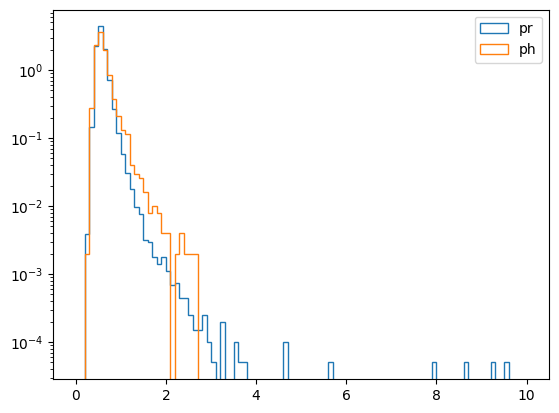

In [35]:
df_knn['particle'] = np.where(df_knn['index'] < num, 'pr', 'ph')
print(df_knn.head(20))
print(df_knn.tail(20))
print(len(df_knn[df_knn['particle'] == 'pr']))
print(len(df_knn[df_knn['particle'] == 'ph']))
print(len(df_knn))
plt.hist(df_knn[df_knn['particle'] == 'pr']['knn_score'], bins=100, label='pr', log=True, density=True, histtype='step', range=(0, 10))
plt.hist(df_knn[df_knn['particle'] == 'ph']['knn_score'], bins=100, label='ph', log=True, density=True, histtype='step', range=(0, 10))
plt.legend()
plt.show()


In [36]:
def lof_anomaly_score(X_scaled, n_neighbors=20):
    """
    LOF на том же самом датасете.
    Чем больше score, тем более аномальна точка.
    """
    lof = LocalOutlierFactor(
        n_neighbors=n_neighbors,
        contamination="auto",
        metric="euclidean",
        novelty=False
    )

    lof.fit_predict(X_scaled)

    # negative_outlier_factor_: чем меньше, тем более аномальна точка
    # поэтому берем минус, чтобы "больше = более аномально"
    scores = -lof.negative_outlier_factor_

    return scores

lof_scores = lof_anomaly_score(X_scaled, n_neighbors=20)

top_idx_lof, top_scores_lof = get_top_anomalies(lof_scores, top_percent=1.0)
df_lof = make_result_df(lof_scores, name="lof_score")

print(df_lof.head(20))
print("Top anomaly indices (LOF):", top_idx_lof[:20])

     index  lof_score
0   133482  10.296289
1   182243   3.495542
2   192482   3.041822
3    16090   2.541739
4    97746   2.408820
5    49765   2.359842
6    71170   2.225150
7   178248   2.150066
8    41170   2.027580
9    34444   1.868908
10  111365   1.665397
11  133757   1.622629
12  201387   1.568406
13   22833   1.539015
14   67179   1.522715
15  179158   1.518486
16  185673   1.509287
17   93383   1.504852
18   26341   1.504705
19  184925   1.492820
Top anomaly indices (LOF): [133482 182243 192482  16090  97746  49765  71170 178248  41170  34444
 111365 133757 201387  22833  67179 179158 185673  93383  26341 184925]


     index  lof_score particle
0   133482  10.296289       pr
1   182243   3.495542       pr
2   192482   3.041822       pr
3    16090   2.541739       pr
4    97746   2.408820       pr
5    49765   2.359842       pr
6    71170   2.225150       pr
7   178248   2.150066       pr
8    41170   2.027580       pr
9    34444   1.868908       pr
10  111365   1.665397       pr
11  133757   1.622629       pr
12  201387   1.568406       ph
13   22833   1.539015       pr
14   67179   1.522715       pr
15  179158   1.518486       pr
16  185673   1.509287       pr
17   93383   1.504852       pr
18   26341   1.504705       pr
19  184925   1.492820       pr
         index  lof_score particle
204980   67620   0.960616       pr
204981  143729   0.960472       pr
204982  191607   0.960451       pr
204983   90248   0.960337       pr
204984   19695   0.959935       pr
204985  137365   0.959808       pr
204986   72840   0.959633       pr
204987  193361   0.959620       pr
204988  156696   0.959465       pr

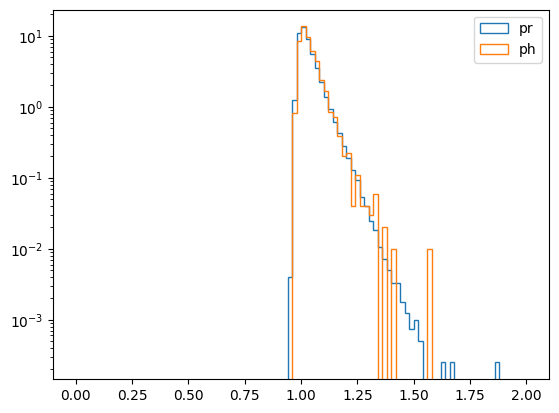

In [42]:
df_lof['particle'] = np.where(df_lof['index'] < num, 'pr', 'ph')
print(df_lof.head(20))
print(df_lof.tail(20))
print(len(df_lof[df_lof['particle'] == 'pr']))
print(len(df_lof[df_lof['particle'] == 'ph']))
print(len(df_lof))
plt.hist(df_lof[df_lof['particle'] == 'pr']['lof_score'], bins=100, label='pr', log=True, density=True, histtype='step', range=(0, 2))
plt.hist(df_lof[df_lof['particle'] == 'ph']['lof_score'], bins=100, label='ph', log=True, density=True, histtype='step', range=(0, 2))
plt.legend()
plt.show()


In [ ]:
num =200000
num_ph = 5000
print(f'part of data {num_ph/num}')
test_num = 10000
print('pr', embading_pr.shape, 'ph', embading_photon.shape)
index = np.random.randint(0, len(embading_pr), num)
index_ph = np.random.randint(0, len(embading_photon), num_ph)
feaches_pr = np.concatenate([embading_pr[index], num_det_pr[index].reshape(-1,1), recon_loss_pr[index].reshape(-1,1), recos_pr[index]], axis=1)

feaches_photon = np.concatenate([embading_photon[index_ph], num_det_photon[index_ph].reshape(-1,1), recon_loss_photon[index_ph].reshape(-1,1), recos_photon[index_ph]], axis=1)

feaches = np.concatenate([feaches_pr, feaches_photon], axis=0)
# label_pr = np.zeros(num)
# label_ph = np.ones(num_ph)
# label = np.concatenate((label_pr, label_ph))
# feaches_pr_test = np.concatenate([embading_pr[-test_num:], num_det_pr[-test_num:].reshape(-1,1), recon_loss_pr[-test_num:].reshape(-1,1)], axis=1)

# feaches_photon_test = np.concatenate([embading_photon[-test_num:], num_det_photon[-test_num:].reshape(-1,1), recon_loss_photon[-test_num:].reshape(-1,1)], axis=1)
# feaches: твой массив shape [N, D]
X = feaches.copy()
print(X.shape)
# Лучше RobustScaler, чем StandardScaler, для задач с выбросами
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

part of data 0.025
pr (210315, 8) ph (210851, 8)
(205000, 25)


In [170]:
def show_2d(pr, ph, use_ph=True):
    # pr_index= np.random.randint(0, pr.shape[0], size=5000)
    # ph_index= np.random.randint(0, ph.shape[0], size=5000)
    # pr = pr[pr_index]
    # ph = ph[ph_index]
    reducer = umap.UMAP(n_components=2)
    if use_ph:
        manifold = reducer.fit(np.concatenate([pr, ph], axis=0))
    else:
        manifold = reducer.fit(pr)
    X_pr = manifold.transform(pr)
    X_ph = manifold.transform(ph)


    fig, ax = plt.subplots(2,3, figsize=(12, 12))
    ax_1, ax_2, ax_3 = ax[0]
    ax_1.scatter(X_pr[:, 0], X_pr[:, 1], s=0.5, alpha=0.3, label='pr')
    ax_2.scatter(X_ph[:, 0], X_ph[:, 1], s=0.5, alpha=0.3, label='ph')
    ax_3.scatter(X_pr[:, 0], X_pr[:, 1], s=0.5, alpha=0.3, label='pr')
    ax_3.scatter(X_ph[:, 0], X_ph[:, 1], s=0.5, alpha=0.3, label='ph')
    ax_1.legend()
    ax_2.legend()
    ax_3.legend()

    tsne = sklearn.manifold.TSNE(n_components=2)
    if use_ph:
        X_tsne = tsne.fit_transform(np.concatenate([pr, ph], axis=0))
        X_tsne_pr = X_tsne[:pr.shape[0]]
        X_tsne_ph = X_tsne[pr.shape[0]:]
    else:
        X_tsne = tsne.fit_transform(pr)
        X_tsne_pr = X_tsne

    ax_1, ax_2, ax_3 = ax[1]
    ax_1.scatter(X_tsne_pr[:, 0], X_tsne_pr[:, 1], s=0.5, alpha=0.3, label='pr')
    ax_2.scatter(X_tsne_ph[:, 0], X_tsne_ph[:, 1], s=0.5, alpha=0.3, label='ph')
    ax_3.scatter(X_tsne_pr[:, 0], X_tsne_pr[:, 1], s=0.5, alpha=0.3, label='pr')
    ax_3.scatter(X_tsne_ph[:, 0], X_tsne_ph[:, 1], s=0.5, alpha=0.3, label='ph')
    ax_1.legend()
    ax_2.legend()
    ax_3.legend()
    plt.show()

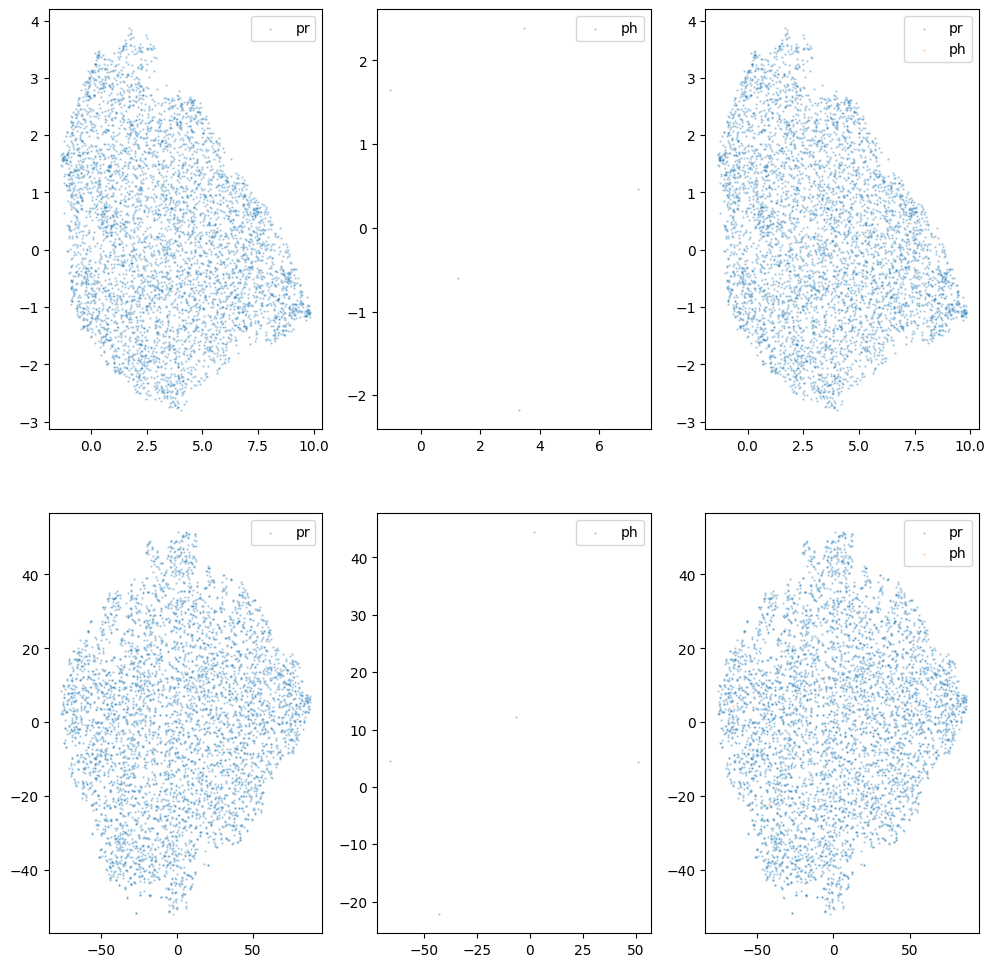

In [209]:
pr = feaches_pr
ph = feaches_photon
show_2d(pr[:5000], ph[:5])

In [243]:
def show_2d_density(pr, ph, use_ph=True, n_ph=1):
    # pr_index= np.random.randint(0, pr.shape[0], size=5000)
    # ph_index= np.random.randint(0, ph.shape[0], size=5000)
    # pr = pr[pr_index]
    # ph = ph[ph_index]
    reducer = umap.UMAP(n_components=2)
    if use_ph:
        manifold = reducer.fit(np.concatenate([pr, ph[::n_ph]], axis=0))
    else:
        manifold = reducer.fit(pr)
    X_pr = manifold.transform(pr)
    X_ph = manifold.transform(ph)

    fig, ax = plt.subplots(2,3, figsize=(12, 12))
    ax_1, ax_2, ax_3 = ax[0]
    ax_1.scatter(X_pr[:, 0], X_pr[:, 1], s=0.5, alpha=0.3, label='pr')
    ax_2.scatter(X_ph[:, 0], X_ph[:, 1], s=0.5, alpha=0.3, label='ph')
    ax_3.scatter(X_pr[:, 0], X_pr[:, 1], s=0.5, alpha=0.3, label='pr')
    ax_3.scatter(X_ph[:, 0], X_ph[:, 1], s=0.5, alpha=0.3, label='ph')
    ax_1.legend()
    ax_2.legend()
    ax_3.legend()

    X_all = np.vstack([X_pr, X_ph[::n_ph]])
    kde = gaussian_kde(X_all.T, )
    density = kde(X_all.T)  # shape: (N,)


    x_min, x_max = X_all[:, 0].min() - 1, X_all[:, 0].max() + 1
    y_min, y_max = X_all[:, 1].min() - 1, X_all[:, 1].max() + 1
    grid_x, grid_y = np.mgrid[x_min:x_max:100j, y_min:y_max:100j]
    density = kde(np.vstack([grid_x.ravel(), grid_y.ravel()]))
    density = density.reshape(grid_x.shape)

    ax_1, ax_2, ax_3 = ax[1]
    # Отображение плотности
    cmap = plt.colormaps['PiYG']
    # (1,0) - плотность для всех точек
    im = ax[1, 0].pcolormesh(grid_x, grid_y, density, cmap=cmap)
    ax[1, 0].set_title('Density (all)')
    fig.colorbar(im, ax=ax[1, 0], label='Density')
    
    ax[1,0].scatter(X_ph[:, 0], X_ph[:, 1],s=1, label='ph')
    # (1,1) и (1,2) можно оставить пустыми или повторить для pr и ph отдельно
    density_ph = kde(X_ph.T)
    density_pr = kde(X_pr.T)
    
    im = ax[1, 2].scatter(X_ph[:, 0], X_ph[:, 1], s=1, label='ph', c=density_ph, cmap='viridis')
    ax[1, 2].set_title('Density (ph)')
    fig.colorbar(im, ax=ax[1, 2], label='Density')
    
    ax[1,1].hist(density_ph, bins=100, label='ph', histtype='step', density=True, log=True)
    ax[1,1].hist(density_pr, bins=100, label='pr', histtype='step', density=True, log=True)
    ax[1,1].legend()
    ax[1,1].set_title('Density (ph and pr)')
    ax[1,1].grid()

    plt.tight_layout()
    plt.show()

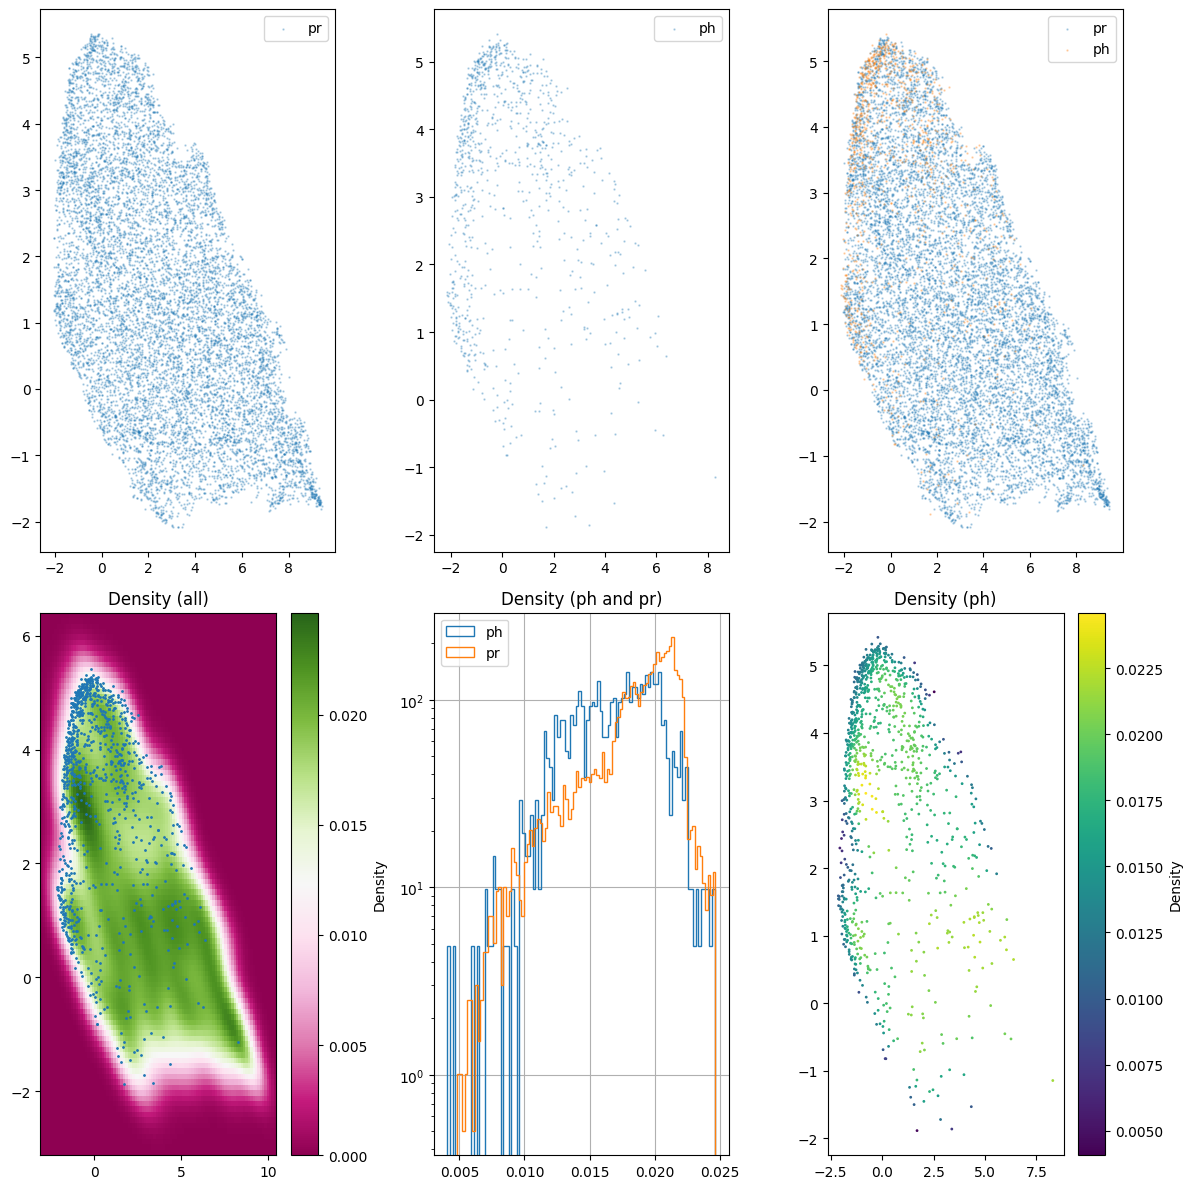

In [244]:
show_2d_density(pr[:10000],ph[:1000], n_ph=50)

In [245]:
def get_metrics(score_samples, score_samples_photon, th):
    FP_index = np.where(score_samples > th)[0]
    TP_index = np.where(score_samples_photon > th)[0]
    FN_index = np.where(score_samples_photon > th)[0]
    TN_index = np.where(score_samples < th)[0]
    part_anomalys_pr = len(FP_index)/len(score_samples)
    part_anomalys_ph = len(TP_index)/len(score_samples_photon)
    recall = len(TP_index) / (len(TP_index) + len(FN_index)+1e-10)
    precision = len(TP_index) / (len(TP_index) + len(FP_index)+1e-10)
    f1 = 2 * precision * recall / (precision + recall+1e-10)
    return recall, precision, f1, part_anomalys_pr, part_anomalys_ph


In [246]:
def iforest_anomaly_score(X_scaled, n_estimators=300, max_samples="auto", random_state=42):
    """
    Isolation Forest.
    Чем больше score, тем более аномальна точка.
    """
    clf = IsolationForest(
        n_estimators=n_estimators,
        max_samples=max_samples,
        contamination=0.025,
        random_state=random_state,
        n_jobs=-1
    )

    clf.fit(X_scaled)

    # score_samples: больше = более нормальная точка
    # берем минус, чтобы больше = более аномальная
    scores = -clf.score_samples(X_scaled)

    return scores

iforest_scores = iforest_anomaly_score(X_scaled[:,:8], n_estimators=100, random_state=42)

top_idx_iforest, top_scores_iforest = get_top_anomalies(iforest_scores, top_percent=1.0)
df_iforest = make_result_df(iforest_scores, name="iforest_score")

print(df_iforest.head(20))
print("Top anomaly indices (IsolationForest):", top_idx_iforest[:20])

     index  iforest_score
0   199205       0.600746
1   204559       0.598141
2   181738       0.597518
3    76491       0.595240
4   202526       0.594120
5   142975       0.592832
6   170614       0.591994
7   144736       0.591249
8   116491       0.591142
9   183446       0.591044
10   54756       0.591044
11  191280       0.591044
12  149993       0.591044
13   75044       0.591044
14   15224       0.590602
15   61198       0.589933
16  141366       0.589737
17  115781       0.589737
18  194262       0.589737
19  137486       0.588681
Top anomaly indices (IsolationForest): [199205 204559 181738  76491 202526 142975 170614 144736 116491  54756
 149993 191280 183446  75044  15224  61198 141366 194262 115781 137486]


     index  iforest_score particle
0   199205       0.600746       pr
1   204559       0.598141       ph
2   181738       0.597518       pr
3    76491       0.595240       pr
4   202526       0.594120       ph
5   142975       0.592832       pr
6   170614       0.591994       pr
7   144736       0.591249       pr
8   116491       0.591142       pr
9   183446       0.591044       pr
10   54756       0.591044       pr
11  191280       0.591044       pr
12  149993       0.591044       pr
13   75044       0.591044       pr
14   15224       0.590602       pr
15   61198       0.589933       pr
16  141366       0.589737       pr
17  115781       0.589737       pr
18  194262       0.589737       pr
19  137486       0.588681       pr
         index  iforest_score particle
204980   39435       0.384480       pr
204981  179556       0.384183       pr
204982   13471       0.384183       pr
204983   68231       0.384183       pr
204984  110512       0.384183       pr
204985   31425       0.384085  

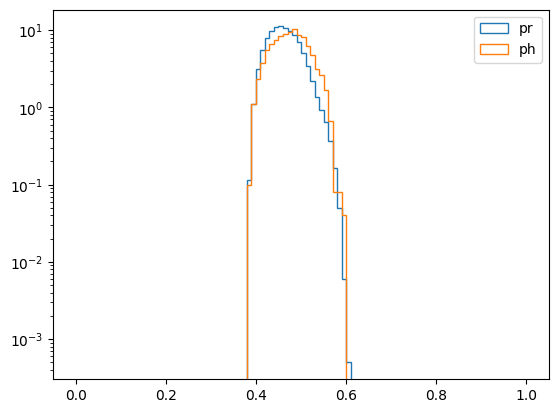

In [247]:
df_iforest['particle'] = np.where(df_iforest['index'] < num, 'pr', 'ph')
print(df_iforest.head(20))
print(df_iforest.tail(20))
print(len(df_iforest[df_iforest['particle'] == 'pr']))
print(len(df_iforest[df_iforest['particle'] == 'ph']))
print(len(df_iforest))
plt.hist(df_iforest[df_iforest['particle'] == 'pr']['iforest_score'], bins=100, label='pr', log=True, density=True, histtype='step', range=(0, 1))
plt.hist(df_iforest[df_iforest['particle'] == 'ph']['iforest_score'], bins=100, label='ph', log=True, density=True, histtype='step', range=(0, 1))
plt.legend()
plt.show()


(200000,) (5000,)


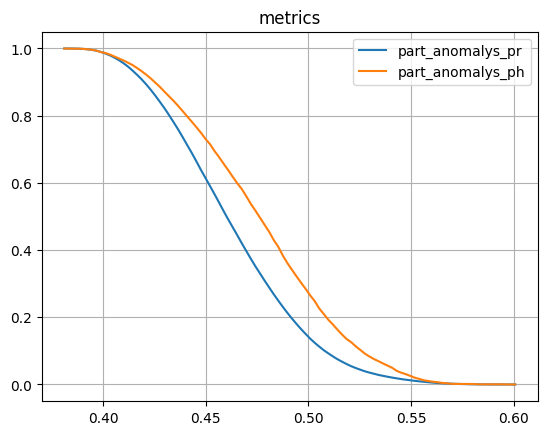

In [248]:
value = np.array(df_iforest['iforest_score'])
label_df = np.where(df_iforest['particle'] == 'pr', 0, 1)
score_samples = value[label_df == 0]
score_samples_photon = value[label_df == 1]
print(score_samples.shape, score_samples_photon.shape)
recall_list = []    
precision_list = []
f1_list = []
part_anomalys_pr_list = []
part_anomalys_ph_list = []
min_score = min(score_samples.min(), score_samples_photon.min())
max_score = max(score_samples.max(), score_samples_photon.max())
for th in np.linspace(min_score, max_score, 100):
    recall, precision, f1, part_anomalys_pr, part_anomalys_ph = get_metrics(score_samples, score_samples_photon, th)
    recall_list.append(recall)
    precision_list.append(precision)
    f1_list.append(f1)
    part_anomalys_pr_list.append(part_anomalys_pr)
    part_anomalys_ph_list.append(part_anomalys_ph)
# plt.plot(np.linspace(min_score, max_score, 100), recall_list, label='recall')
# plt.plot(np.linspace(min_score, max_score, 100), precision_list, label='precision')
# plt.plot(np.linspace(min_score, max_score, 100), f1_list, label='f1')
plt.plot(np.linspace(min_score, max_score, 100), part_anomalys_pr_list, label='part_anomalys_pr')
plt.plot(np.linspace(min_score, max_score, 100), part_anomalys_ph_list, label='part_anomalys_ph')
plt.legend()
plt.title('metrics')
plt.grid()

(205000,) (20500,)


array([0.64776374, 0.64672486, 0.64639783, ..., 0.37885231, 0.37707813,
       0.37707813])

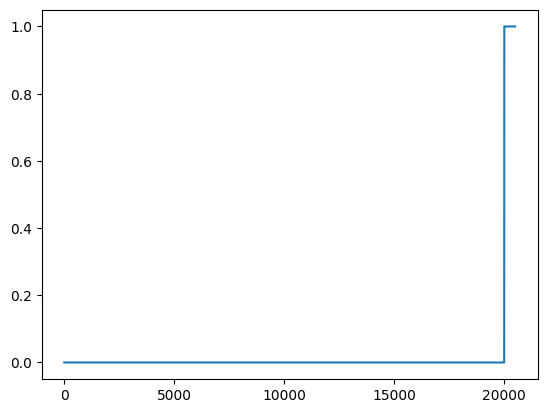

In [214]:
plt.plot(label)

(200000,) (5000,)


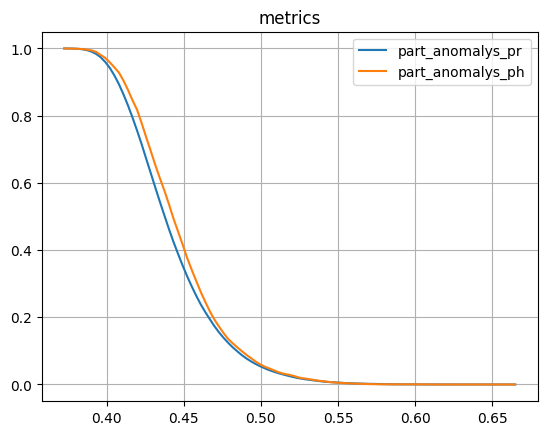

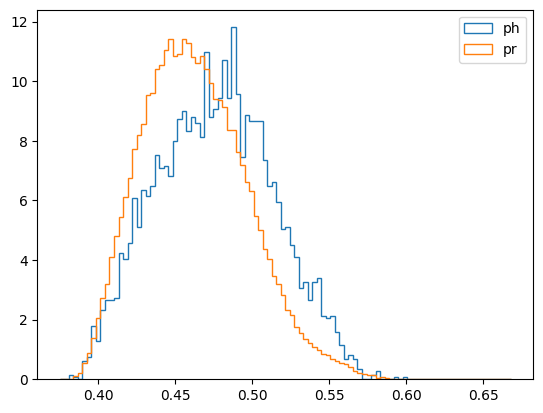

array([0.60074601, 0.5981414 , 0.59751834, ..., 0.38121134, 0.38121134,
       0.38115516])

In [230]:
plt.hist(score_samples_photon, bins=100, label='ph', histtype='step', density=True, range=(0.375, 0.668))
plt.hist(score_samples, bins=100, label='pr', histtype='step', density=True, range=(0.375, 0.668))
plt.legend()
plt.show()
value


In [ ]:
value = np.array(df_iforest['iforest_score'])
score_samples = value[label_df == 0]
particle = np.where(df_iforest['particle'] == 'pr', 0, 1)    
val_df = np.array(df_iforest[df_iforest['particle'] == 'pr']['iforest_score'])
print(particle)
score_samples, val_df, val_df.shape, score_samples.shape

[0 0 0 ... 0 0 0]


(array([0.66665223, 0.66506656, 0.6619735 , ..., 0.40278789, 0.40278504,
        0.40278377]),
 array([0.66665223, 0.66506656, 0.6619735 , ..., 0.38009508, 0.3795069 ,
        0.37820867]),
 (200000,),
 (200000,))

In [102]:
score_samples, val_df, val_df.shape, score_samples.shape

(array([0.66665223, 0.66506656, 0.6619735 , ..., 0.38009508, 0.3795069 ,
        0.37820867]),
 array([0.66665223, 0.66506656, 0.6619735 , ..., 0.38009508, 0.3795069 ,
        0.37820867]),
 (200000,),
 (200000,))

(array([0.        , 0.        , 0.06825939, 0.        , 0.75085324,
        0.40955631, 0.75085324, 1.29692833, 1.9112628 , 2.93515358,
        3.13993174, 4.02730375, 4.84641638, 5.39249147, 6.27986348,
        6.48464164, 7.44027304, 7.09897611, 7.30375427, 7.03071672,
        7.37201365, 5.80204778, 7.91808874, 8.73720137, 8.66894198,
        7.91808874, 8.60068259, 8.05460751, 8.60068259, 8.73720137,
        9.82935154, 8.25938567, 9.82935154, 8.19112628, 8.46416382,
        7.37201365, 7.91808874, 7.57679181, 7.98634812, 7.50853242,
        8.32764505, 6.27986348, 6.6894198 , 6.82593857, 7.03071672,
        6.27986348, 5.05119454, 5.05119454, 5.46075085, 4.36860068,
        4.36860068, 4.98293515, 3.54948805, 3.95904437, 4.3003413 ,
        2.11604096, 3.07167235, 3.20819113, 3.3447099 , 2.45733788,
        2.59385666, 2.32081911, 2.11604096, 1.22866894, 1.09215017,
        0.88737201, 0.40955631, 0.54607509, 0.20477816, 0.27303754,
        0.34129693, 0.27303754, 0.40955631, 0.13

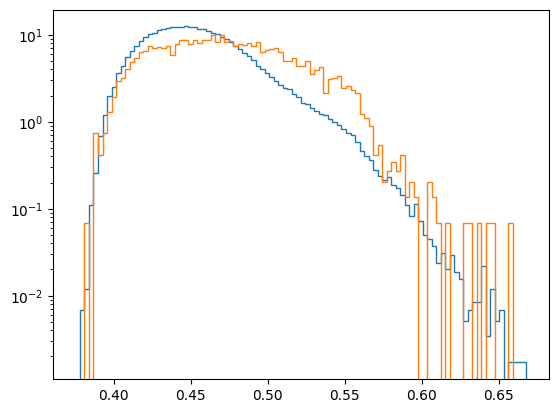

In [101]:
plt.hist(df_iforest[df_iforest['particle'] == 'pr']['iforest_score'], bins=100, label='pr', log=True, density=True, histtype='step', range=(0.375, 0.668))
plt.hist(df_iforest[df_iforest['particle'] == 'ph']['iforest_score'], bins=100, label='ph', log=True, density=True, histtype='step', range=(0.375, 0.668))


In [ ]:
    axs[0].hist(score_samples, bins=100, label='pr', histtype='step', density=True, range=range_hist)
    axs[0].hist(score_samples_photon, bins=100, label='ph', histtype='step', density=True, range=range_hist)
    axs[0].legend()
    axs[0].set_title('hist')
    axs[0].grid()

    recall_list = []    
    precision_list = []
    f1_list = []
    part_anomalys_pr_list = []
    part_anomalys_ph_list = []
    min_score = min(score_samples.min(), score_samples_photon.min())
    max_score = max(score_samples.max(), score_samples_photon.max())
    for th in np.linspace(min_score, max_score, 100):
        recall, precision, f1, part_anomalys_pr, part_anomalys_ph = get_metrics(score_samples, score_samples_photon, th)
        recall_list.append(recall)
        precision_list.append(precision)
        f1_list.append(f1)
        part_anomalys_pr_list.append(part_anomalys_pr)
        part_anomalys_ph_list.append(part_anomalys_ph)
    axs[1].plot(np.linspace(-20, 2, 100), recall_list, label='recall')
    axs[1].plot(np.linspace(-20, 2, 100), precision_list, label='precision')
    axs[1].plot(np.linspace(-20, 2, 100), f1_list, label='f1')
    axs[1].plot(np.linspace(-20, 2, 100), part_anomalys_pr_list, label='part_anomalys_pr')
    axs[1].plot(np.linspace(-20, 2, 100), part_anomalys_ph_list, label='part_anomalys_ph')
    axs[1].legend()
    axs[1].set_title('metrics')
    axs[1].grid()

    #roc curve
    label_pr = np.zeros_like(score_samples)
    label_ph = np.ones_like(score_samples_photon)
    label = np.concatenate((label_pr, label_ph))
    loss = np.concatenate((-score_samples, -score_samples_photon))
    fpr, tpr, thresholds = roc_curve(label, loss)
    auc_ = auc(fpr, tpr)
    axs[2].plot(fpr, tpr)
    axs[2].text(0.5, 0.5, f'auc: {auc_:.2f}', fontsize=12, ha='center', va='center')
    axs[2].set_title(f'roc curve')
    axs[2].grid()
    print(thresholds.min(), thresholds.max())
    plt.show()

In [27]:
#KDE
from sklearn.neighbors import KernelDensity

# Создаем объект KernelDensity
kde = KernelDensity(kernel='gaussian', bandwidth=0.1)


kde.fit(X_scaled)

# Оцениваем плотность вероятности для всех точек
# densities = kde.score_samples(X_scaled)

# top_idx_kde, top_scores_kde = get_top_anomalies(densities, top_percent=1.0)
# df_kde = make_result_df(densities, name="kde_score")

# print(df_kde.head(20))
# print("Top anomaly indices (IsolationForest):", df_kde[:20])

KernelDensity(bandwidth=0.1)

In [31]:
kde.score_samples(X_scaled[:10])

array([1.60898781, 1.60637351, 1.60572833, 1.61028898, 1.60571929,
       1.62744346, 1.6061886 , 1.67589482, 1.60662242, 1.60581596])

In [29]:
from tqdm import tqdm
n=100
all_densities = []
for i in tqdm(range(int(len(X_scaled)/n))):
    all_densities.append(kde.score_samples(X_scaled[i*n:(i+1)*n]))
# all_densities = np.concatenate(all_densities)
# top_idx_kde, top_scores_kde = get_top_anomalies(all_densities, top_percent=1.0)
# df_kde = make_result_df(all_densities, name="kde_score")

# print(df_kde.head(20))
# print("Top anomaly indices (IsolationForest):", df_kde[:20])

  1%|          | 16/2050 [00:27<58:49,  1.74s/it] 


KeyboardInterrupt: 

In [160]:
from sklearn.neighbors import KernelDensity

# Создаем объект KernelDensity
kde = KernelDensity(kernel='gaussian', bandwidth=0.3)


kde.fit(X_scaled)

KernelDensity(bandwidth=0.3)

In [163]:
feaches_photon.shape , feaches_pr.shape

((5000, 10), (200000, 10))

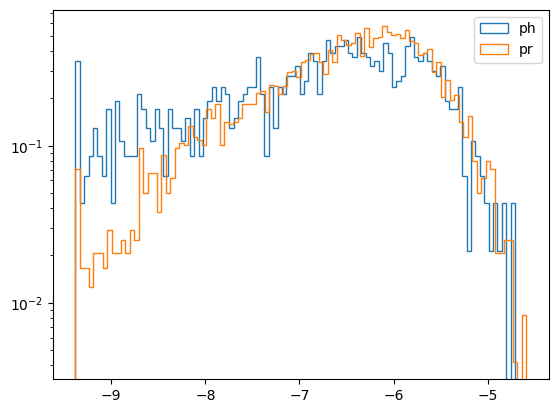

In [162]:
scores_ph = kde.score_samples(X_scaled[-1000:])
scores_pr = kde.score_samples(X_scaled[:5000])
plt.hist(scores_ph, bins=100, label='ph', log=True, density=True, histtype='step')
plt.hist(scores_pr, bins=100, label='pr', log=True, density=True, histtype='step')
plt.legend()
plt.show()

